In [1]:
cd("d:/Master Research/Research-Project")

In [7]:
include(joinpath(@__DIR__, "Parameter", "parameter.jl"))
include(joinpath(@__DIR__, "Helper_util", "util.jl"));

In [25]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(5, 0, 0)


total_population=Total_Population(0.4).total


## parameter setting up 2
Nₜ = global_parameter_1.Nₜ
λ, ν = global_parameter_1.λ, global_parameter_1.ν
δ, g, m = global_parameter_1.δ, global_parameter_1.g, global_parameter_1.m
d₁, d₂, d₃= diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃;
d₁_vec=Diffusion_Vec_Parameter(0.1:0.1:10).d_vec;


In [46]:
function characteristic_poly(N̄, P̄, Z̄, d₁, d₂, d₃, k)
    
    f₁=-ν*P̄/((1+N̄)^2)
    f₂=-ν*(N̄/(N̄+1))+ m*λ*P̄^(m-1)
    f₃=δ

    g₁=ν*P̄/((1+N̄)^2)
    g₂=ν*(N̄/(N̄+1))-g*Z̄/((1+Z̄)^2)-m*λ*P̄^(m-1)
    g₃=-g*P̄/(1+P̄)

    h₁=0
    h₂=g*Z̄/((1+P̄)^2)
    h₃=0
    

    b₀= -(-f₂*g₁*h₃ + f₁*g₂*h₃ - f₃*g₂*h₁ + f₂*g₃*h₁ + f₃*g₁*h₂ - f₁*g₃*h₂) + d₁*d₂*d₃*(k^6) + (d₁*d₂*h₃ + d₁*d₃*g₂ + d₂*d₃*f₁)*(k^4) + d₁*(k^2)*(g₃*h₂- g₂*h₃) + d₂*(k^2)*(f₃*h₁- f₁*h₃)+ d₃*(k^2)*(f₂*g₁- f₁*g₂)
    b₁= - (f₁*g₁ - f₂*g₂- f₁*h₃ + g₂*h₃ + h₂*g₃) - (k^2)*(d₂+d₃)*f₁ - (k^2)*(d₁+d₃)*g₂ - (k^2)*(d₂+d₁)*h₃ + (k^4)*(d₂*d₁ + d₂*d₃+ d₃*d₁)
    b₂=-(f₁ + g₂ + h₃) + (k^2)*(d₁+d₂+d₃)

    poly = Polynomial([b₀, b₁, b₂, 1])

    roots_poly = roots(poly)

    # Compute real parts and find the maximum
    max_real_root = maximum(real.(roots_poly))


    x_vals = -1:0.001:1
    y_vals = poly.(x_vals)

    plt = plot(x_vals, y_vals,
        xlabel = "x", ylabel = "p(x)",
        title = "Characteristic Polynomial",
        legend = false, lw = 2)

    y_max_real = poly(max_real_root)
    scatter!([max_real_root], [y_max_real], color = :red, label = "Max Re(root)")


    display(plt)
    return(b₀, b₁, b₂, max_real_root)
end


characteristic_poly (generic function with 1 method)

In [ ]:
N̄, P̄, Z̄= equilibrium_state_3D(total_population, λ, ν, δ, g, m)
N̄, P̄, Z̄=N̄[1], P̄[1], Z̄[1]

(0.2295901925831683, 0.024890190336749635, 0.1455196170800821)

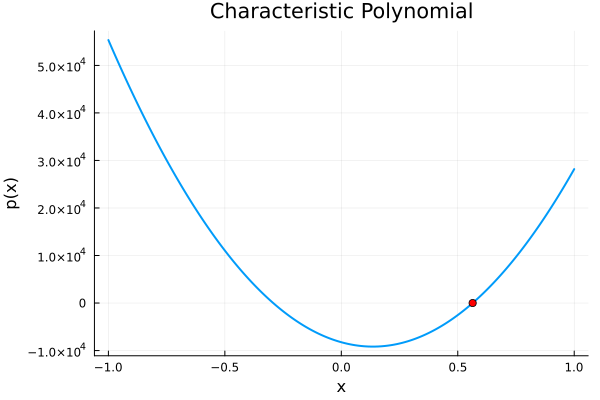

(-8242.972222037124, -13575.264551737922, 49999.82562826781, 0.5638714939326948)

In [61]:
k=100
b₀, b₁, b₂, pde_eigen=characteristic_poly(N̄, P̄, Z̄, d₁, d₂, d₃, k)

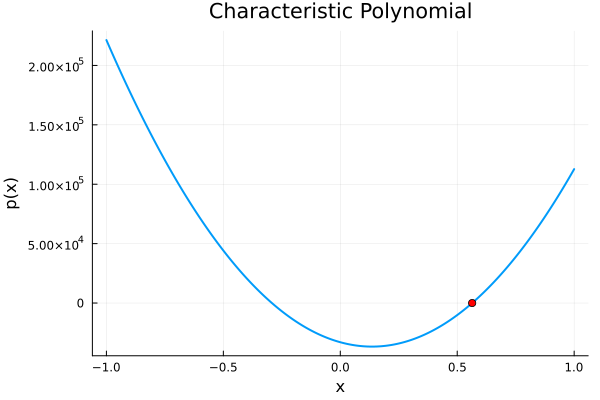

(-32971.888888148496, -54300.72766539859, 199999.8256282678, 0.5638725750648375)

In [62]:
k=200
b₀, b₁, b₂, pde_eigen=characteristic_poly(N̄, P̄, Z̄, d₁, d₂, d₃, k)